EDA to Understand Data , detect missing, null , invalid values and find outliers.

To Anaylze data distribution and based on that select algorithms and train the model.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fact = pd.read_csv("fact_zone_hour (1).csv")
dim_weather = pd.read_csv("dim_weather_hour.csv")
dim_zone = pd.read_csv("dim_zone.csv")
dim_holiday = pd.read_csv("dim_holidays_tel.csv")

print("data Loaded successfully")




data Loaded successfully


In [41]:
print(fact.shape)
print(fact.columns)
fact.head()

(438600, 36)
Index(['ts_hour', 'date', 'zone_id', 'zone_name', 'year', 'month', 'day',
       'dow', 'hour', 'is_weekend', 'is_holiday', 'is_general_holiday',
       'holiday_name', 'holiday_category', 'pre_holiday_flag',
       'post_holiday_flag', 'is_ramadan', 'is_ramadan_evening', 'is_eid',
       'temp_c', 'is_rain', 'rain_mm', 'traffic_index', 'event_intensity_city',
       'requests', 'available_drivers', 'avg_eta_min', 'surge_multiplier',
       'avg_trip_km', 'avg_fare_inr', 'cancel_rate', 'avg_rating',
       'requests_lag_1', 'requests_lag_24', 'requests_roll_3', 'is_peak'],
      dtype='str')


,ts_hour,date,zone_id,zone_name,year,month,day,dow,hour,is_weekend,...,avg_eta_min,surge_multiplier,avg_trip_km,avg_fare_inr,cancel_rate,avg_rating,requests_lag_1,requests_lag_24,requests_roll_3,is_peak
0,2024-04-01T09:00:00.000Z,2024-04-01T00:00:00.000Z,HYD_004,Kondapur,2024,4,1,0,9,0,...,24.15,2.06,5.40,175.23,0.305,4.15,43.0,51.0,39.000000,1
1,2024-04-01T10:00:00.000Z,2024-04-01T00:00:00.000Z,HYD_004,Kondapur,2024,4,1,0,10,0,...,18.20,1.67,5.05,122.68,0.230,4.39,52.0,46.0,44.666667,1
2,2024-04-01T11:00:00.000Z,2024-04-01T00:00:00.000Z,HYD_004,Kondapur,2024,4,1,0,11,0,...,10.54,1.27,5.29,110.39,0.127,4.46,39.0,20.0,36.000000,0
3,2024-04-01T12:00:00.000Z,2024-04-01T00:00:00.000Z,HYD_004,Kondapur,2024,4,1,0,12,0,...,13.60,1.49,4.66,125.18,0.156,4.43,17.0,22.0,28.333333,1
4,2024-04-01T13:00:00.000Z,2024-04-01T00:00:00.000Z,HYD_004,Kondapur,2024,4,1,0,13,0,...,9.25,1.09,4.26,73.63,0.096,4.61,29.0,22.0,21.333333,0


In [23]:
def basic_info(df : pd.DataFrame, name: str, n : int=5) -> None:
    print(f"\n{'='*100}\n Dataset :{'='*100}")
    print(f"Shape :{df.shape}")
    print("-"*100)
    print(df.head(n))
    print("-"*100)
    display(df.dtypes)

basic_info(fact, "FACT_ZONE_HOUR")
basic_info(dim_zone, "DIM_ZONE")
basic_info(dim_weather, "DIM_WEATHER_HOUR")
basic_info(dim_holiday, "DIM_HOLIDAYS_TEL")


 Dataset :====================================================================================================
Shape :(438600, 36)
----------------------------------------------------------------------------------------------------
                    ts_hour                      date  zone_id zone_name  \
0  2024-04-01T09:00:00.000Z  2024-04-01T00:00:00.000Z  HYD_004  Kondapur   
1  2024-04-01T10:00:00.000Z  2024-04-01T00:00:00.000Z  HYD_004  Kondapur   
2  2024-04-01T11:00:00.000Z  2024-04-01T00:00:00.000Z  HYD_004  Kondapur   
3  2024-04-01T12:00:00.000Z  2024-04-01T00:00:00.000Z  HYD_004  Kondapur   
4  2024-04-01T13:00:00.000Z  2024-04-01T00:00:00.000Z  HYD_004  Kondapur   

   year  month  day  dow  hour  is_weekend  ...  avg_eta_min  \
0  2024      4    1    0     9           0  ...        24.15   
1  2024      4    1    0    10           0  ...        18.20   
2  2024      4    1    0    11           0  ...        10.54   
3  2024      4    1    0    12           0  ...       

ts_hour                     str
date                        str
zone_id                     str
zone_name                   str
year                      int64
month                     int64
day                       int64
dow                       int64
hour                      int64
is_weekend                int64
is_holiday                int64
is_general_holiday        int64
holiday_name                str
holiday_category            str
pre_holiday_flag          int64
post_holiday_flag         int64
is_ramadan                int64
is_ramadan_evening        int64
is_eid                    int64
temp_c                  float64
is_rain                   int64
rain_mm                 float64
traffic_index           float64
event_intensity_city    float64
requests                  int64
available_drivers         int64
avg_eta_min             float64
surge_multiplier        float64
avg_trip_km             float64
avg_fare_inr            float64
cancel_rate             float64
avg_rati


 Dataset :====================================================================================================
Shape :(25, 6)
----------------------------------------------------------------------------------------------------
   zone_id    zone_name  demand_potential  supply_potential  \
0  HYD_001  Hitech City          1.517641          1.024403   
1  HYD_002   Gachibowli          1.255064          0.746781   
2  HYD_003     Madhapur          1.452403          1.082654   
3  HYD_004     Kondapur          1.380757          0.867859   
4  HYD_005   Kukatpally          0.941462          0.935827   

   distance_km_to_center  affluence_index  
0                    4.8         1.291889  
1                   18.0         1.238679  
2                    3.5         1.448630  
3                   21.7         1.101454  
4                   17.4         1.800000  
----------------------------------------------------------------------------------------------------


zone_id                      str
zone_name                    str
demand_potential         float64
supply_potential         float64
distance_km_to_center    float64
affluence_index          float64
dtype: object


 Dataset :====================================================================================================
Shape :(17544, 5)
----------------------------------------------------------------------------------------------------
                    ts_hour     temp_c  is_rain    rain_mm  traffic_index
0  2024-07-01T18:00:00.000Z  27.196087        0   0.000000       1.237954
1  2024-07-01T19:00:00.000Z  30.882452        1  15.324081       1.496269
2  2024-07-01T20:00:00.000Z  28.823128        0   0.000000       1.275786
3  2024-07-01T21:00:00.000Z  29.932908        0   0.000000       0.992925
4  2024-07-01T22:00:00.000Z  26.048121        1   4.076442       1.220168
----------------------------------------------------------------------------------------------------


ts_hour              str
temp_c           float64
is_rain            int64
rain_mm          float64
traffic_index    float64
dtype: object


 Dataset :====================================================================================================
Shape :(54, 7)
----------------------------------------------------------------------------------------------------
                       date        holiday_name  holiday_year holiday_type  \
0  2024-01-01T00:00:00.000Z        New Year Day          2024      GENERAL   
1  2024-01-14T00:00:00.000Z               Bhogi          2024      GENERAL   
2  2024-01-15T00:00:00.000Z  Sankranti / Pongal          2024      GENERAL   
3  2024-01-26T00:00:00.000Z        Republic Day          2024      GENERAL   
4  2024-03-08T00:00:00.000Z     Maha Shivaratri          2024      GENERAL   

  holiday_category  holiday_weight  is_public_holiday  
0      State/Other             1.4                  1  
1      State/Other             1.4                  1  
2         Festival             1.4                  1  
3         National             1.4                  1  
4      State/Other     

date                     str
holiday_name             str
holiday_year           int64
holiday_type             str
holiday_category         str
holiday_weight       float64
is_public_holiday      int64
dtype: object

In [24]:
def missing_analysis(df: pd.DataFrame, name: str)-> pd.DataFrame:
    out=(
        df.isna().mean().mul(100).reset_index().rename(columns={"index":"column", 0: "missing_pct"}).sort_values("missing_pct", ascending= False)
    )


    print(f"\n Missing Value Summary:{name}")
    display(out)
    return out


missing_analysis(fact, "FACT_ZONE_HOUR")
missing_analysis(dim_zone, "DIM_ZONE")
missing_analysis(dim_weather, "DIM_WEATHER_HOUR")
missing_analysis(dim_holiday, "DIM_HOLIDAYS_TEL")


 Missing Value Summary:FACT_ZONE_HOUR


,column,missing_pct
12,holiday_name,92.612859
13,holiday_category,92.612859
0,ts_hour,0.000000
1,date,0.000000
3,zone_name,0.000000
2,zone_id,0.000000
4,year,0.000000
5,month,0.000000
8,hour,0.000000
9,is_weekend,0.000000



 Missing Value Summary:DIM_ZONE


,column,missing_pct
0,zone_id,0.0
1,zone_name,0.0
2,demand_potential,0.0
3,supply_potential,0.0
4,distance_km_to_center,0.0
5,affluence_index,0.0



 Missing Value Summary:DIM_WEATHER_HOUR


,column,missing_pct
0,ts_hour,0.0
1,temp_c,0.0
2,is_rain,0.0
3,rain_mm,0.0
4,traffic_index,0.0



 Missing Value Summary:DIM_HOLIDAYS_TEL


,column,missing_pct
0,date,0.0
1,holiday_name,0.0
2,holiday_year,0.0
3,holiday_type,0.0
4,holiday_category,0.0
5,holiday_weight,0.0
6,is_public_holiday,0.0


,column,missing_pct
0,date,0.0
1,holiday_name,0.0
2,holiday_year,0.0
3,holiday_type,0.0
4,holiday_category,0.0
5,holiday_weight,0.0
6,is_public_holiday,0.0


In [25]:
def numeric_summary_single_table(df: pd.DataFrame, name:str, percentile= None)-> pd.DataFrame:
    if percentile is None:
        percentiles =[0.01, 0.05, 0.50, 0.95, 0.99]

    num_cols = df.select_dtypes(include = np.number).columns.tolist()

    if not num_cols:
        print(f"\n{name}: No numeric columns found.")
        return pd.DataFrame()
    
    desc = df[num_cols].describe(percentiles = percentiles).T
    desc["mean_minus_median"]=(desc["mean"]-desc["50%"]).astype(float)
    desc.insert(0, "column", desc.index)
    desc = desc.sort_values("mean_minus_median", ascending=False).reset_index(drop=True)



    print(f"\n Numeric Summary (Single table)-{name}")
    display(desc)
    return desc


numeric_summary_single_table(fact, "FACT_ZONE_HOUR")
numeric_summary_single_table(dim_zone, "DIM_ZONE")
numeric_summary_single_table(dim_weather, "DIM_WEATHER_HOUR")
numeric_summary_single_table(dim_holiday, "DIM_HOLIDAYS_TEL")


 Numeric Summary (Single table)-FACT_ZONE_HOUR


,column,count,mean,std,min,1%,5%,50%,95%,99%,max,mean_minus_median
0,avg_fare_inr,438600.0,105.503993,30.309884,40.000000,57.110000,67.710000,100.010000,160.760000,206.540000,360.130000,5.493993
1,requests_lag_1,438600.0,18.635572,13.028588,0.000000,2.000000,4.000000,15.000000,45.000000,58.000000,105.000000,3.635572
2,requests,438600.0,18.635169,13.028849,0.000000,2.000000,4.000000,15.000000,45.000000,58.000000,105.000000,3.635169
3,requests_lag_24,438600.0,18.632513,13.022177,0.000000,2.000000,4.000000,15.000000,45.000000,58.000000,105.000000,3.632513
4,requests_roll_3,438600.0,18.635801,11.014280,0.666667,3.666667,5.666667,16.000000,40.333333,51.666667,90.666667,2.635801
5,available_drivers,438600.0,12.220511,6.771252,0.000000,2.000000,4.000000,11.000000,25.000000,31.000000,48.000000,1.220511
6,avg_eta_min,438600.0,10.333492,5.505541,2.500000,2.500000,3.670000,9.200000,20.830000,30.150000,35.000000,1.133492
7,rain_mm,438600.0,0.592620,2.213515,0.000000,0.000000,0.000000,0.000000,4.979714,11.654110,29.750475,0.592620
8,year,438600.0,2024.499316,0.500000,2024.000000,2024.000000,2024.000000,2024.000000,2025.000000,2025.000000,2025.000000,0.499316
9,is_peak,438600.0,0.410705,0.491962,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.410705



 Numeric Summary (Single table)-DIM_ZONE


,column,count,mean,std,min,1%,5%,50%,95%,99%,max,mean_minus_median
0,distance_km_to_center,25.0,11.528000,6.383150,2.100000,2.388000,3.340000,11.400000,19.620000,21.220000,21.700000,0.128000
1,demand_potential,25.0,1.024181,0.305463,0.521680,0.532982,0.577341,0.941466,1.504593,1.610402,1.639695,0.082715
2,supply_potential,25.0,0.938008,0.201380,0.600000,0.602911,0.624650,0.935827,1.222245,1.365517,1.407501,0.002181
3,affluence_index,25.0,1.074287,0.288043,0.551484,0.556978,0.604276,1.077135,1.441216,1.715671,1.800000,-0.002848



 Numeric Summary (Single table)-DIM_WEATHER_HOUR


,column,count,mean,std,min,1%,5%,50%,95%,99%,max,mean_minus_median
0,rain_mm,17544.0,0.592620,2.213576,0.000000,0.000000,0.000000,0.000000,4.979561,11.646113,29.750475,0.592620
1,temp_c,17544.0,27.921507,3.747407,17.333319,20.528362,22.289942,27.620459,34.937421,37.164704,40.474597,0.301049
2,is_rain,17544.0,0.098837,0.298452,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.098837
3,traffic_index,17544.0,1.121103,0.189030,0.718852,0.825494,0.883625,1.060553,1.452985,1.595288,1.805509,0.060549



 Numeric Summary (Single table)-DIM_HOLIDAYS_TEL


,column,count,mean,std,min,1%,5%,50%,95%,99%,max,mean_minus_median
0,holiday_weight,54.0,1.4,6.723887e-16,1.4,1.4,1.4,1.4,1.4,1.4,1.4,6.661338e-16
1,holiday_year,54.0,2024.5,5.046949e-01,2024.0,2024.0,2024.0,2024.5,2025.0,2025.0,2025.0,0.000000e+00
2,is_public_holiday,54.0,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000e+00


,column,count,mean,std,min,1%,5%,50%,95%,99%,max,mean_minus_median
0,holiday_weight,54.0,1.4,6.723887e-16,1.4,1.4,1.4,1.4,1.4,1.4,1.4,6.661338e-16
1,holiday_year,54.0,2024.5,5.046949e-01,2024.0,2024.0,2024.0,2024.5,2025.0,2025.0,2025.0,0.000000e+00
2,is_public_holiday,54.0,1.0,0.000000e+00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000e+00



 Plotting numeric distributions -FACT_ZONE_HOUR (first20 numeric columns)


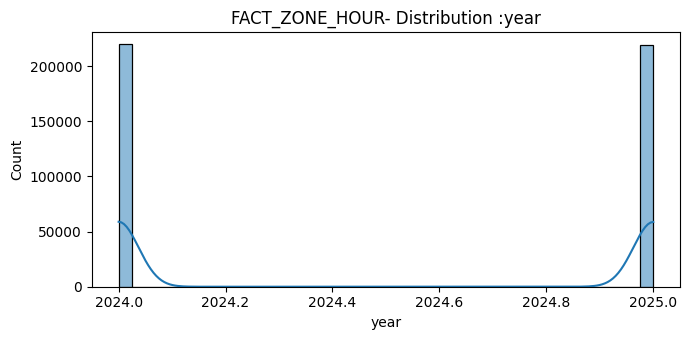

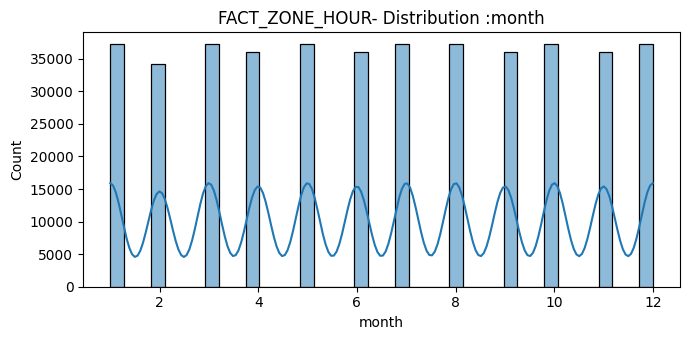

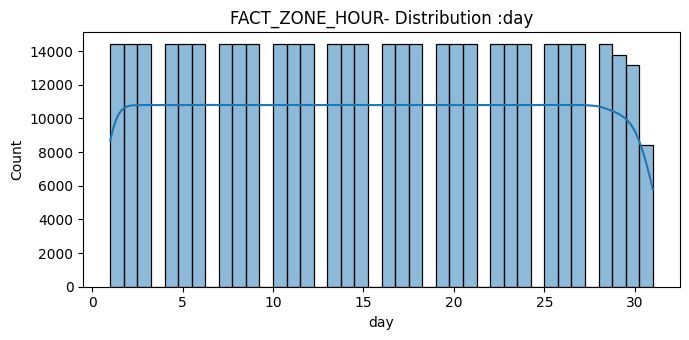

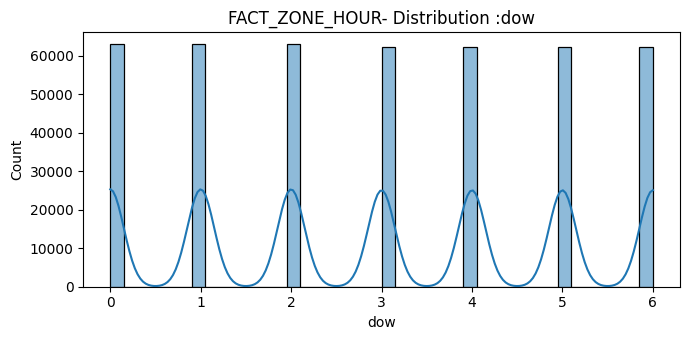

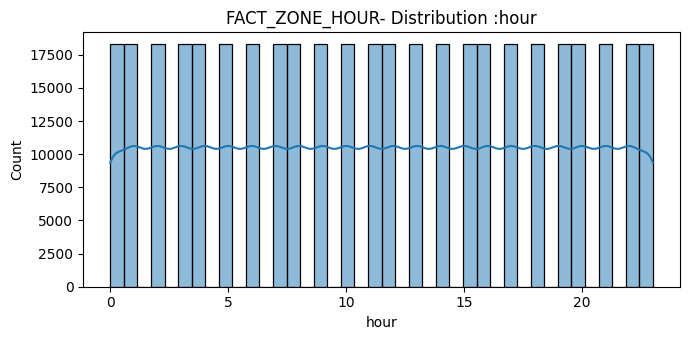

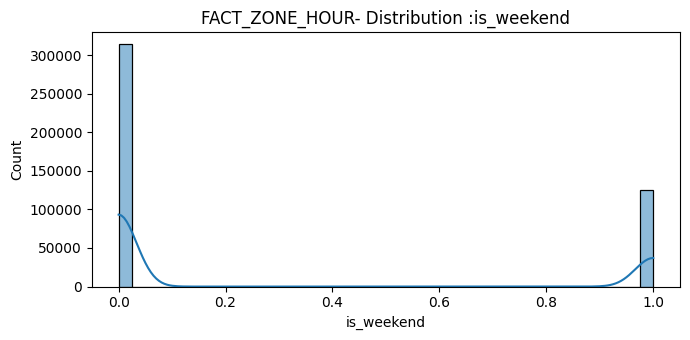

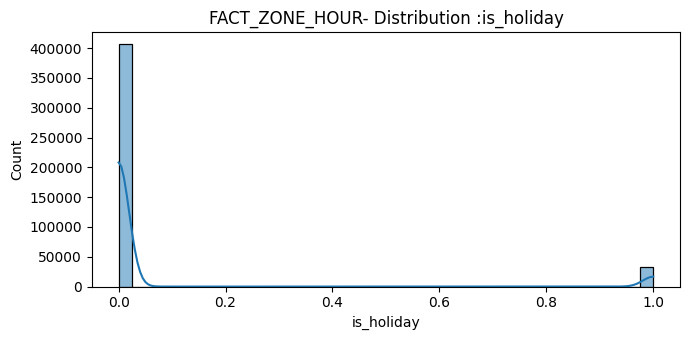

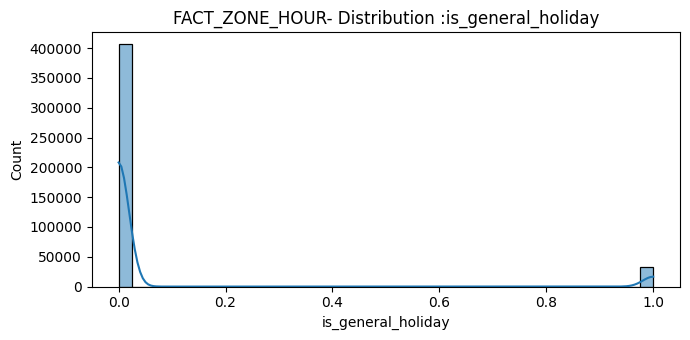

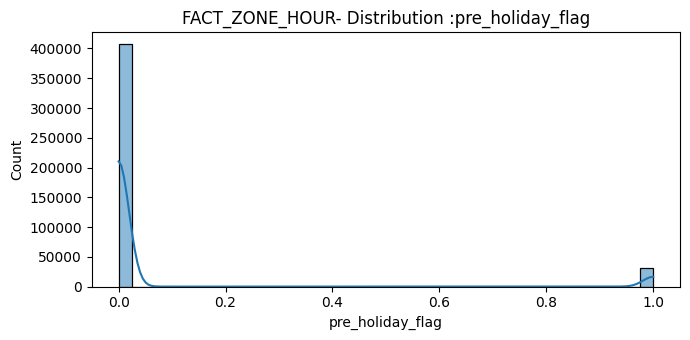

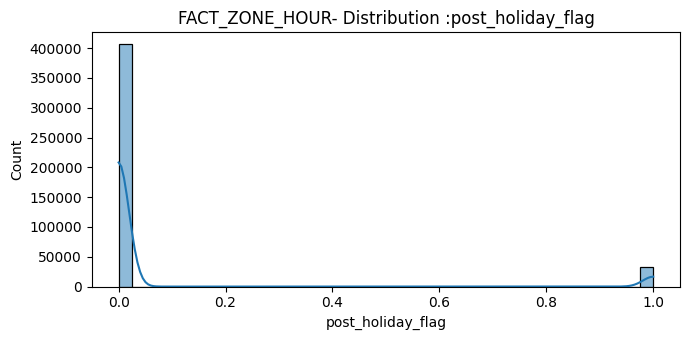

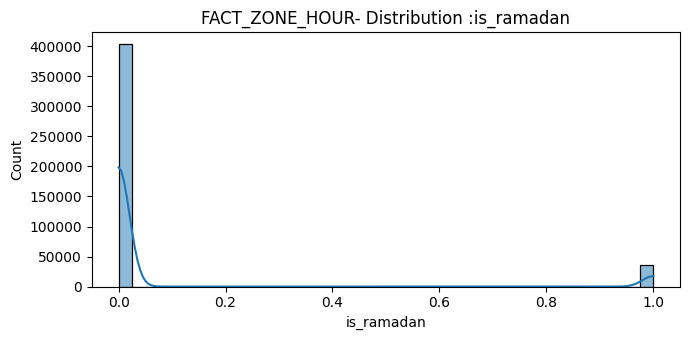

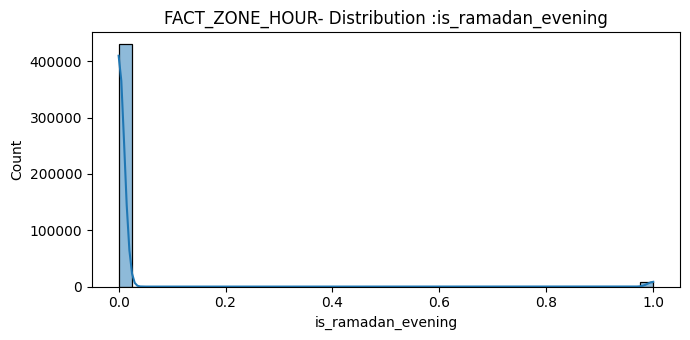

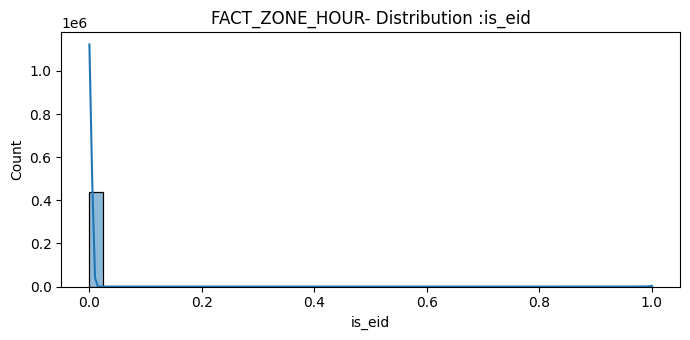

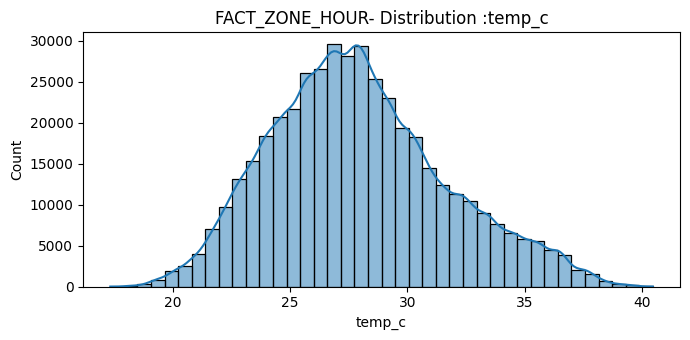

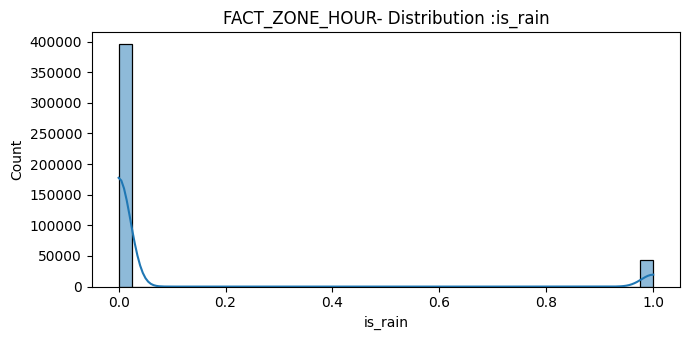

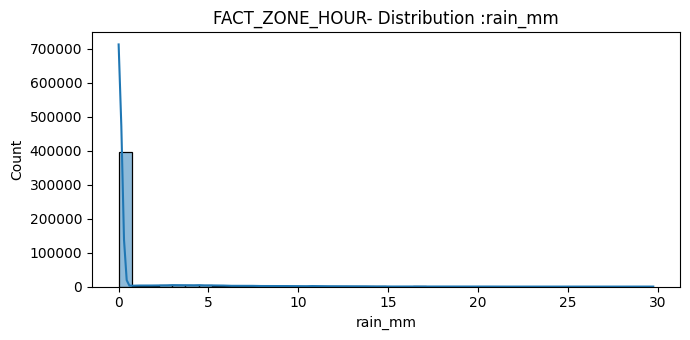

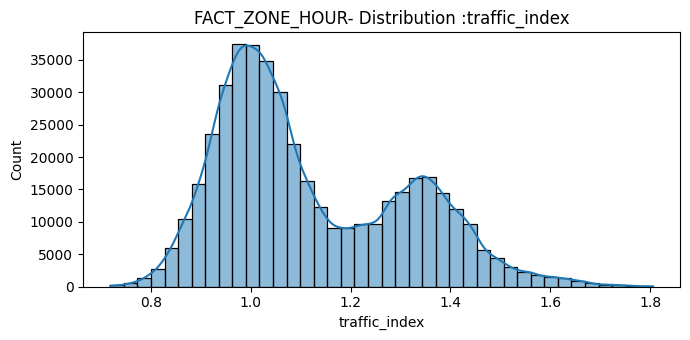

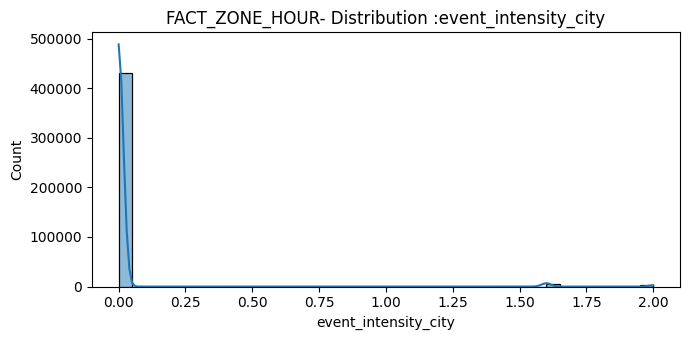

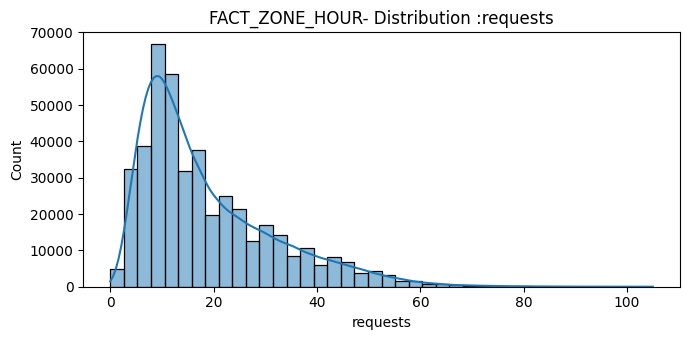

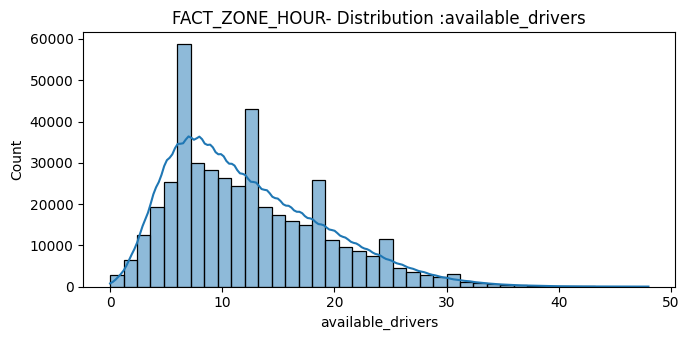


 Plotting numeric distributions -DIM_ZONE (first4 numeric columns)


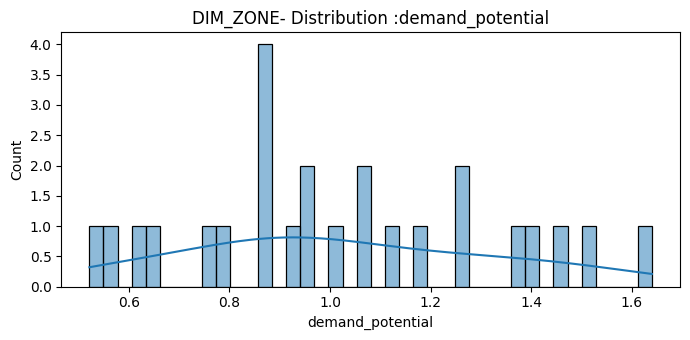

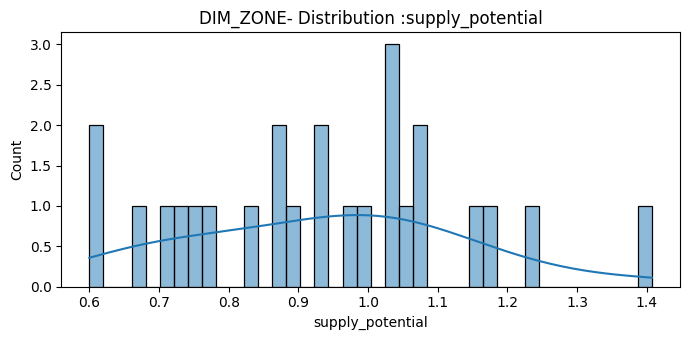

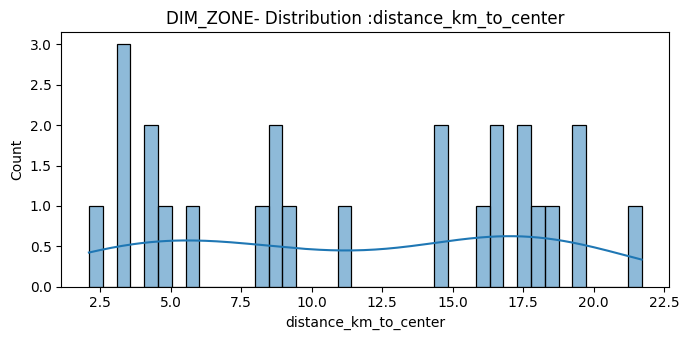

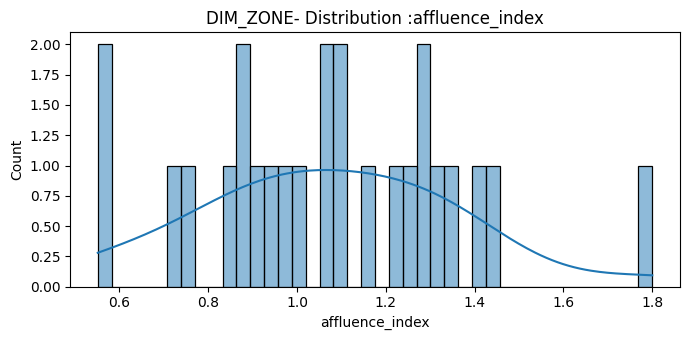


 Plotting numeric distributions -DIM_WEATHER_HOUR (first4 numeric columns)


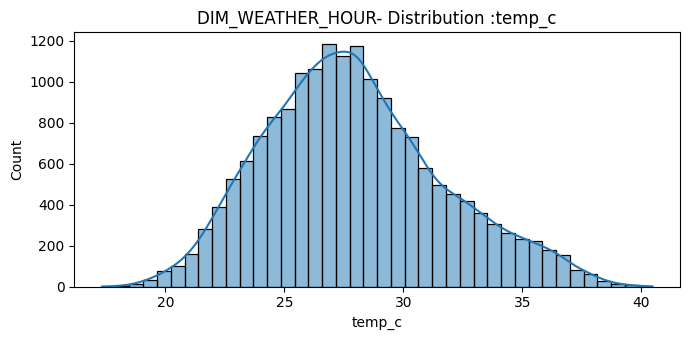

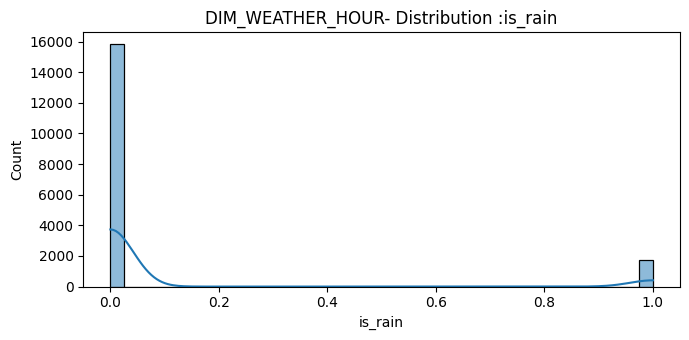

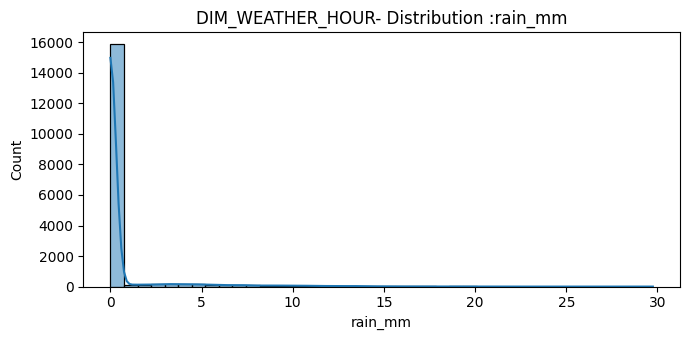

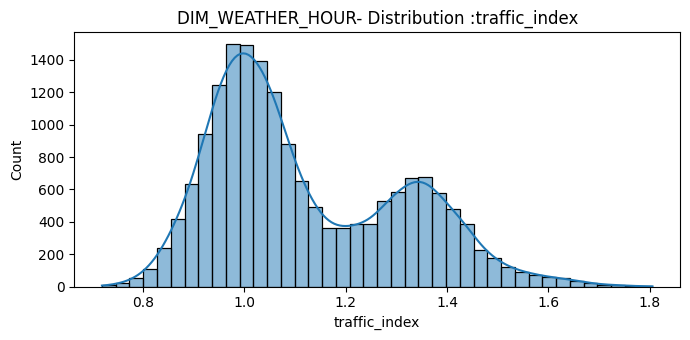


 Plotting numeric distributions -DIM_HOLIDAYS_TEL (first3 numeric columns)


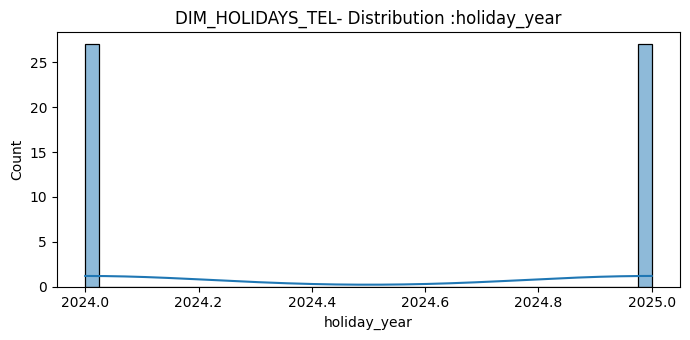

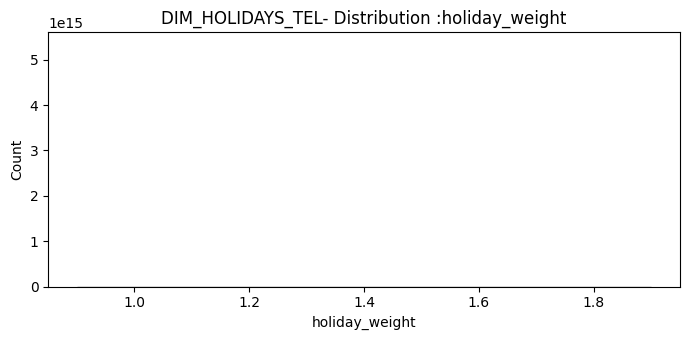

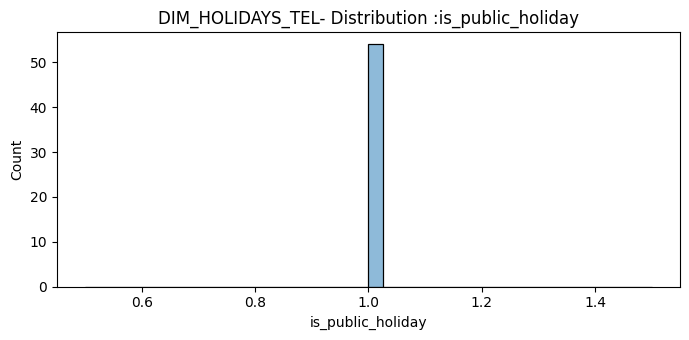

In [26]:
def plot_numeric_distributions(df: pd.DataFrame, name: str, max_plots: int=20)-> None:
    num_cols = df.select_dtypes(include = np.number).columns.tolist()


    if not num_cols:
        print(f"\n{name}: No numeric columns found.")
        return
    
    cols_to_plot = num_cols[:max_plots]
    print(f"\n Plotting numeric distributions -{name} (first{len(cols_to_plot)} numeric columns)")



    for col in cols_to_plot:
        x = df[col].dropna()

        plt.figure(figsize=(7, 3.5))
        sns.histplot(x, bins=40, kde= True)
        plt.title(f"{name}- Distribution :{col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


plot_numeric_distributions(fact, "FACT_ZONE_HOUR")
plot_numeric_distributions(dim_zone, "DIM_ZONE")
plot_numeric_distributions(dim_weather, "DIM_WEATHER_HOUR")
plot_numeric_distributions(dim_holiday, "DIM_HOLIDAYS_TEL")

In [27]:
def categorical_summary(
    df: pd.DataFrame,
    name: str,
    top_n: int = 10,
    max_cols :int=25,
    include_numeric_ids: bool= True,
    cardinality_cap : int = 2000
)-> None:
    cat_cols = df.select_dtypes(include=["object","category","bool"]).columns.tolist()
    if include_numeric_ids :
        num_cols = df.select_dtypes(include =[np.number]).columns.tolist()
        low_card_num = [c for c in num_cols if df[c].nunique(dropna= True)<=200]
        cat_cols = list(dict.fromkeys(cat_cols + low_card_num))

    print(f"\n Categorical Columns ({name}): {len(cat_cols)}")
    if not cat_cols:
        print("No categorical  like columns found")
        return
    cat_cols = cat_cols[:max_cols]
    for col in cat_cols:
        nunique = df[col].nunique(dropna= True)
        if nunique> cardinality_cap:
            print(f"\n{name} - Column :{col}(skipped; cardinality={nunique})")
            continue
        vc_counts= df[col].value_counts(dropna=False).head(top_n)
        vc_pct = (df[col].value_counts(dropna=False, normalize= True).head(top_n)*100).round(2)
        out= pd.DataFrame({
            "value": vc_counts.index.astype(str),
            "count": vc_counts.values,
            "pct": vc_pct.values
        })
        print(f"\n{name} - Column :{col} (cardinality={nunique})")
        display(out)


categorical_summary(fact, "FACT_ZONE_HOUR")
categorical_summary(dim_zone, "DIM_ZONE")
categorical_summary(dim_weather, "DIM_WEATHER_HOUR")
categorical_summary(dim_holiday, "DIM_HOLIDAYS_TEL")


C:\Users\kukut\AppData\Local\Temp\ipykernel_27912\2827041646.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object","category","bool"]).columns.tolist()



 Categorical Columns (FACT_ZONE_HOUR): 27

FACT_ZONE_HOUR - Column :ts_hour(skipped; cardinality=17544)

FACT_ZONE_HOUR - Column :date (cardinality=731)


,value,count,pct
0,2024-04-01T00:00:00.000Z,600,0.14
1,2024-04-02T00:00:00.000Z,600,0.14
2,2024-04-03T00:00:00.000Z,600,0.14
3,2024-04-04T00:00:00.000Z,600,0.14
4,2024-04-05T00:00:00.000Z,600,0.14
5,2024-04-06T00:00:00.000Z,600,0.14
6,2024-04-07T00:00:00.000Z,600,0.14
7,2024-04-08T00:00:00.000Z,600,0.14
8,2024-04-09T00:00:00.000Z,600,0.14
9,2024-04-10T00:00:00.000Z,600,0.14



FACT_ZONE_HOUR - Column :zone_id (cardinality=25)


,value,count,pct
0,HYD_004,17544,4.0
1,HYD_005,17544,4.0
2,HYD_006,17544,4.0
3,HYD_007,17544,4.0
4,HYD_019,17544,4.0
5,HYD_020,17544,4.0
6,HYD_021,17544,4.0
7,HYD_022,17544,4.0
8,HYD_001,17544,4.0
9,HYD_002,17544,4.0


...

,value,count,pct
0,2024,27,50.0
1,2025,27,50.0



DIM_HOLIDAYS_TEL - Column :holiday_weight (cardinality=1)


,value,count,pct
0,1.4,54,100.0



DIM_HOLIDAYS_TEL - Column :is_public_holiday (cardinality=1)


,value,count,pct
0,1,54,100.0


In [42]:
fact.info()


<class 'pandas.DataFrame'>
RangeIndex: 438600 entries, 0 to 438599
Data columns (total 36 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ts_hour               438600 non-null  str    
 1   date                  438600 non-null  str    
 2   zone_id               438600 non-null  str    
 3   zone_name             438600 non-null  str    
 4   year                  438600 non-null  int64  
 5   month                 438600 non-null  int64  
 6   day                   438600 non-null  int64  
 7   dow                   438600 non-null  int64  
 8   hour                  438600 non-null  int64  
 9   is_weekend            438600 non-null  int64  
 10  is_holiday            438600 non-null  int64  
 11  is_general_holiday    438600 non-null  int64  
 12  holiday_name          32400 non-null   str    
 13  holiday_category      32400 non-null   str    
 14  pre_holiday_flag      438600 non-null  int64  
 15  post_holida

In [29]:
fact.describe()

,year,month,day,dow,hour,is_weekend,is_holiday,is_general_holiday,pre_holiday_flag,post_holiday_flag,...,avg_eta_min,surge_multiplier,avg_trip_km,avg_fare_inr,cancel_rate,avg_rating,requests_lag_1,requests_lag_24,requests_roll_3,is_peak
count,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,...,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000,438600.000000
mean,2024.499316,6.519836,15.738714,2.991792,11.500000,0.284542,0.073871,0.073871,0.072503,0.073871,...,10.333492,1.282738,4.762803,105.503993,0.120421,4.534888,18.635572,18.632513,18.635801,0.410705
std,0.500000,3.449555,8.803931,2.000669,6.922194,0.451196,0.261562,0.261562,0.259320,0.261562,...,5.505541,0.314943,0.724030,30.309884,0.072107,0.187937,13.028588,13.022177,11.014280,0.491962
min,2024.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.500000,1.000000,1.480000,40.000000,0.010000,3.530000,0.000000,0.000000,0.666667,0.000000
25%,2024.000000,4.000000,8.000000,1.000000,5.750000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.480000,1.040000,4.270000,84.930000,0.070000,4.440000,9.000000,9.000000,10.000000,0.000000
50%,2024.000000,7.000000,16.000000,3.000000,11.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.200000,1.200000,4.760000,100.010000,0.106000,4.560000,15.000000,15.000000,16.000000,0.000000
75%,2025.000000,10.000000,23.000000,5.000000,17.250000,1.000000,0.000000,0.000000,0.000000,0.000000,...,12.870000,1.410000,5.250000,119.960000,0.154000,4.660000,25.000000,25.000000,25.000000,1.000000
max,2025.000000,12.000000,31.000000,6.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,35.000000,3.500000,8.120000,360.130000,0.506000,5.000000,105.000000,105.000000,90.666667,1.000000


<Axes: xlabel='requests', ylabel='Count'>

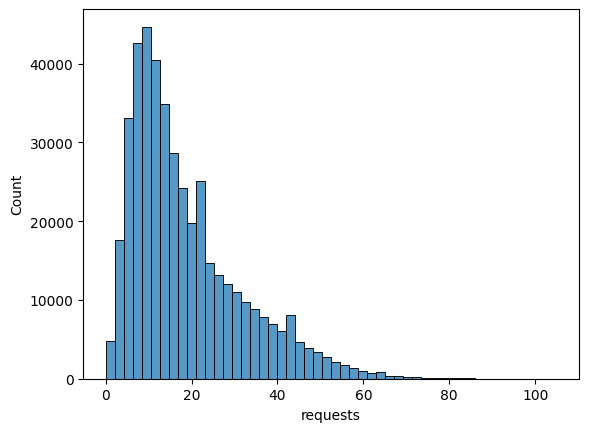

In [30]:
sns.histplot(fact['requests'], bins = 50)

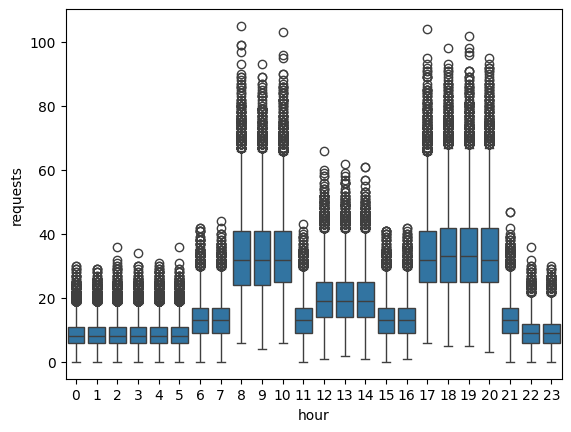

In [31]:
sns.boxplot(x = 'hour', y = 'requests', data = fact)
plt.show()

In [35]:
features = [
    'available_drivers',
    'rain_mm',
    'traffic_index',
    'event_intensity_city',
    'hour'
]
TARGET = "requests"

model_df = fact[features + [TARGET]].copy()
model_df.dropna(inplace=True)

In [36]:
from sklearn.model_selection import train_test_split
x = model_df[features]
y = model_df[TARGET]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)


In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

preds = model.predict(x_test)

In [38]:
from sklearn.metrics import r2_score, mean_absolute_error

In [39]:
print("R2 Score:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R2 Score: 0.5232239506628057
MAE: 6.724012596028463
